In [42]:
import sys
sys.path.append('..')

import torch
from torch.utils.data import DataLoader

from src.model import ECG_CNN1D
from src.dataset import ECGDataset
from src.losses import FocalLossMultiLabel
from src.train import entrenar_una_epoca, evaluar
from src.utils import fijar_semilla
fijar_semilla(42)

dispositivo = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Usando dispositivo:", dispositivo)



Usando dispositivo: cpu


In [43]:
train_dataset = ECGDataset('../data/processed/X_train.npy', '../data/processed/y_train.npy')
val_dataset = ECGDataset('../data/processed/X_val.npy', '../data/processed/y_val.npy')

# num_workers=0: en Windows + Jupyter, valores mayores pueden causar errores
# de multiprocessing. Con un dataset de este tamaño, 0 es igualmente rápido.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Ejemplos de entrenamiento: {len(train_dataset)}")
print(f"Ejemplos de validación: {len(val_dataset)}")

Ejemplos de entrenamiento: 17074
Ejemplos de validación: 2144


In [44]:
modelo = ECG_CNN1D(num_leads=12, num_classes=5).to(dispositivo)
funcion_perdida = FocalLossMultiLabel(alpha=0.25, gamma=2.0)
optimizador = torch.optim.Adam(modelo.parameters(), lr=1e-3)

SMOKE TEST:

In [45]:
from torch.utils.data import Subset

subset_train = Subset(train_dataset, range(200))
subset_val = Subset(val_dataset, range(100))

subset_train_loader = DataLoader(subset_train, batch_size=32, shuffle=True, num_workers=0)
subset_val_loader = DataLoader(subset_val, batch_size=32, shuffle=False, num_workers=0)

modelo_prueba = ECG_CNN1D(num_leads=12, num_classes=5).to(dispositivo)
optimizador_prueba = torch.optim.Adam(modelo_prueba.parameters(), lr=1e-3)

for epoca in range(2):
    perdida_train = entrenar_una_epoca(modelo_prueba, subset_train_loader, funcion_perdida, optimizador_prueba, dispositivo)
    perdida_val, _, _ = evaluar(modelo_prueba, subset_val_loader, funcion_perdida, dispositivo)
    print(f"Época {epoca+1}: pérdida train={perdida_train:.4f}, pérdida val={perdida_val:.4f}")

Época 1: pérdida train=0.0945, pérdida val=0.0933


Época 2: pérdida train=0.0603, pérdida val=0.0617


In [46]:
import os
os.makedirs('../models', exist_ok=True)

from sklearn.metrics import roc_auc_score

NUM_EPOCAS = 40
mejor_auroc_val = 0.0
mejor_epoca = 0

historial = {'perdida_train': [], 'perdida_val': [], 'auroc_val': []}

for epoca in range(NUM_EPOCAS):
    perdida_train = entrenar_una_epoca(modelo, train_loader, funcion_perdida, optimizador, dispositivo)
    perdida_val, predicciones_val, etiquetas_val = evaluar(modelo, val_loader, funcion_perdida, dispositivo)
    auroc_val = roc_auc_score(etiquetas_val, predicciones_val, average='macro')

    historial['perdida_train'].append(perdida_train)
    historial['perdida_val'].append(perdida_val)
    historial['auroc_val'].append(auroc_val)

    print(f"Época {epoca+1}/{NUM_EPOCAS} | Pérdida train: {perdida_train:.4f} | Pérdida val: {perdida_val:.4f} | AUROC val (macro): {auroc_val:.4f}")

    if auroc_val > mejor_auroc_val:
        mejor_auroc_val = auroc_val
        mejor_epoca = epoca + 1
        torch.save(modelo.state_dict(), '../models/mejor_modelo.pt')
        print(f"  → Nuevo mejor modelo guardado (AUROC: {auroc_val:.4f})")

print(f"\nEntrenamiento completo. Mejor AUROC macro: {mejor_auroc_val:.4f} (época {mejor_epoca})")

Época 1/40 | Pérdida train: 0.0398 | Pérdida val: 0.0338 | AUROC val (macro): 0.8826
  → Nuevo mejor modelo guardado (AUROC: 0.8826)


Época 2/40 | Pérdida train: 0.0340 | Pérdida val: 0.0333 | AUROC val (macro): 0.8890
  → Nuevo mejor modelo guardado (AUROC: 0.8890)


Época 3/40 | Pérdida train: 0.0328 | Pérdida val: 0.0329 | AUROC val (macro): 0.8941
  → Nuevo mejor modelo guardado (AUROC: 0.8941)


Época 4/40 | Pérdida train: 0.0321 | Pérdida val: 0.0317 | AUROC val (macro): 0.8979
  → Nuevo mejor modelo guardado (AUROC: 0.8979)


Época 5/40 | Pérdida train: 0.0317 | Pérdida val: 0.0322 | AUROC val (macro): 0.8955


...

Época 36/40 | Pérdida train: 0.0246 | Pérdida val: 0.0332 | AUROC val (macro): 0.9029


Época 37/40 | Pérdida train: 0.0245 | Pérdida val: 0.0353 | AUROC val (macro): 0.9038


Época 38/40 | Pérdida train: 0.0244 | Pérdida val: 0.0336 | AUROC val (macro): 0.9053


Época 39/40 | Pérdida train: 0.0242 | Pérdida val: 0.0323 | AUROC val (macro): 0.9049


Época 40/40 | Pérdida train: 0.0239 | Pérdida val: 0.0360 | AUROC val (macro): 0.9042

Entrenamiento completo. Mejor AUROC macro: 0.9114 (época 29)


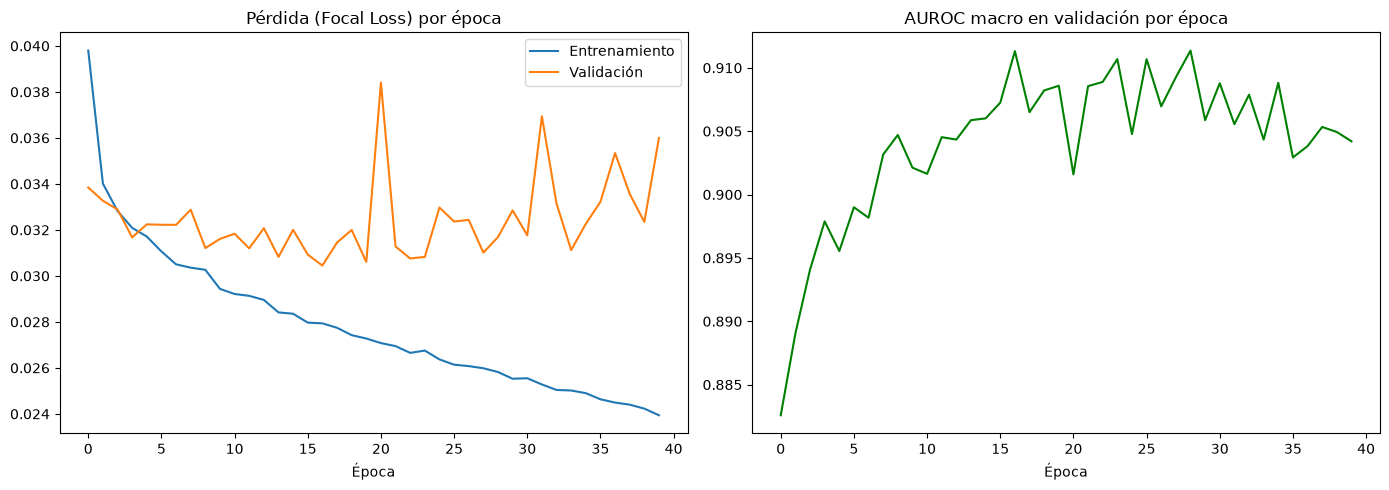

<Figure size 640x480 with 0 Axes>

In [47]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(historial['perdida_train'], label='Entrenamiento')
axes[0].plot(historial['perdida_val'], label='Validación')
axes[0].set_title('Pérdida (Focal Loss) por época')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(historial['auroc_val'], color='green')
axes[1].set_title('AUROC macro en validación por época')
axes[1].set_xlabel('Época')

plt.tight_layout()
plt.show()
plt.tight_layout()
fig.savefig('../assets/curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
modelo_final = ECG_CNN1D(num_leads=12, num_classes=5).to(dispositivo)
modelo_final.load_state_dict(torch.load('../models/mejor_modelo.pt', weights_only=True))
modelo_final.eval()

ECG_CNN1D(
  (bloque1): Sequential(
    (0): Conv1d(12, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloque2): Sequential(
    (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloque3): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): AdaptiveAvgPool1d(output_size=1)
  )
  (clasificador): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=

In [49]:
test_dataset = ECGDataset('../data/processed/X_test.npy', '../data/processed/y_test.npy')
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

_, predicciones_test, etiquetas_test = evaluar(modelo_final, test_loader, funcion_perdida, dispositivo)
print("Predicciones obtenidas para", len(predicciones_test), "ECGs de test")

Predicciones obtenidas para 2156 ECGs de test


In [50]:
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd

CLASES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

resultados = []
for i, clase in enumerate(CLASES):
    auroc = roc_auc_score(etiquetas_test[:, i], predicciones_test[:, i])
    auprc = average_precision_score(etiquetas_test[:, i], predicciones_test[:, i])
    resultados.append({'Clase': clase, 'AUROC': round(auroc, 4), 'AUPRC': round(auprc, 4)})

resultados_df = pd.DataFrame(resultados)

auroc_macro = roc_auc_score(etiquetas_test, predicciones_test, average='macro')
auprc_macro = average_precision_score(etiquetas_test, predicciones_test, average='macro')

print(resultados_df)
print(f"\nAUROC macro (promedio de las 5 clases): {auroc_macro:.4f}")
print(f"AUPRC macro (promedio de las 5 clases): {auprc_macro:.4f}")

  Clase   AUROC   AUPRC
0  NORM  0.9357  0.9104
1    MI  0.9169  0.8199
2  STTC  0.9310  0.8180
3    CD  0.9119  0.8317
4   HYP  0.8323  0.4844

AUROC macro (promedio de las 5 clases): 0.9055
AUPRC macro (promedio de las 5 clases): 0.7729


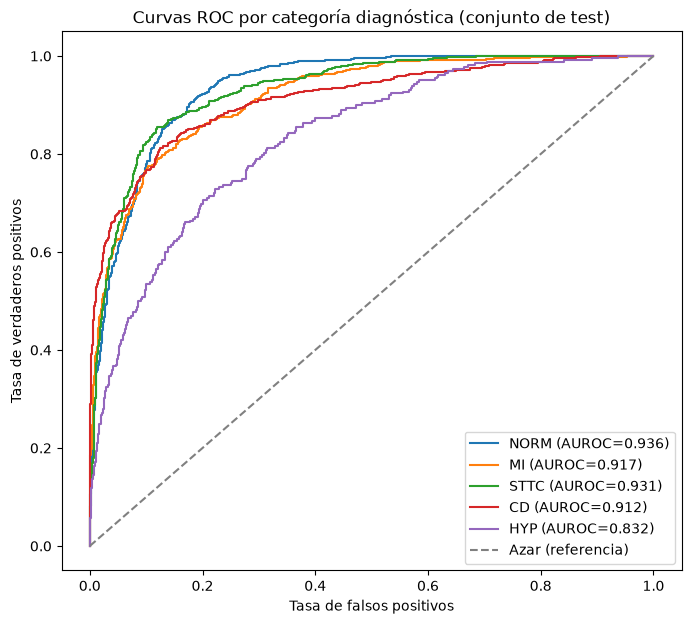

In [51]:
from sklearn.metrics import roc_curve

fig = plt.figure(figsize=(8, 7))
for i, clase in enumerate(CLASES):
    fpr, tpr, _ = roc_curve(etiquetas_test[:, i], predicciones_test[:, i])
    auroc = resultados_df.loc[i, 'AUROC']
    plt.plot(fpr, tpr, label=f'{clase} (AUROC={auroc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar (referencia)')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curvas ROC por categoría diagnóstica (conjunto de test)')
plt.legend()
fig.savefig('../assets/curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

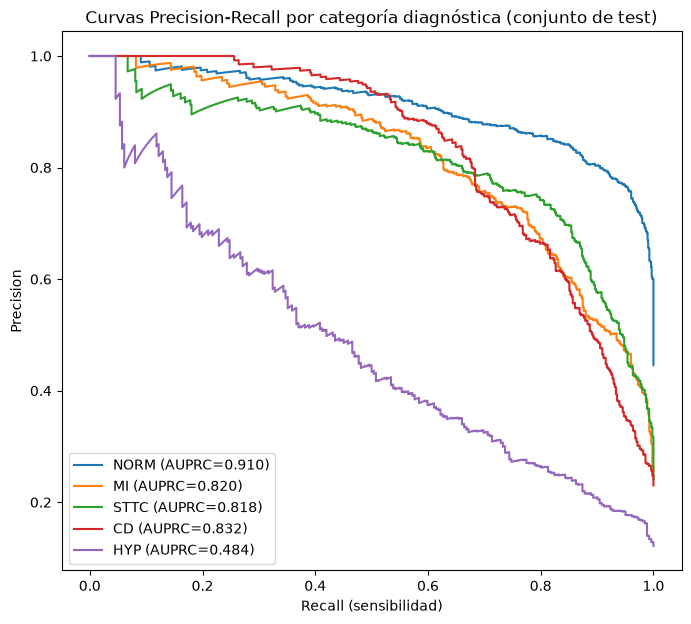

In [52]:
from sklearn.metrics import precision_recall_curve

fig = plt.figure(figsize=(8, 7))
for i, clase in enumerate(CLASES):
    precision, recall, _ = precision_recall_curve(etiquetas_test[:, i], predicciones_test[:, i])
    auprc = resultados_df.loc[i, 'AUPRC']
    plt.plot(recall, precision, label=f'{clase} (AUPRC={auprc:.3f})')

plt.xlabel('Recall (sensibilidad)')
plt.ylabel('Precision')
plt.title('Curvas Precision-Recall por categoría diagnóstica (conjunto de test)')
plt.legend()
fig.savefig('../assets/curvas_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
resultados_df.to_csv('../models/resultados_test.csv', index=False)
print("Resultados guardados en models/resultados_test.csv")

Resultados guardados en models/resultados_test.csv


In [54]:
import os
os.makedirs('../assets', exist_ok=True)